In [1]:
#%matplotlib notebook
import numpy  as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
q = 1.60217662E-19  #elementary charge C
m = 9.10938356E-31 # electron mass kg
pi = np.pi

def bfield_from_ECR(frequency):
    B_field = (1E9*2*pi*m*frequency)/q
    return B_field

def freq_from_bfield(B):
    freq = (q*B)/(1E9*2*pi*m)
    return freq

def format_plot(xlabel,ylabel, title):
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel(xlabel,fontsize=20)
    plt.ylabel(ylabel,fontsize=20)
    plt.title(title, fontsize = 22)
    plt.ticklabel_format(useOffset=False)
    #plt.legend(fontsize = 16)

## Magnet Configuration

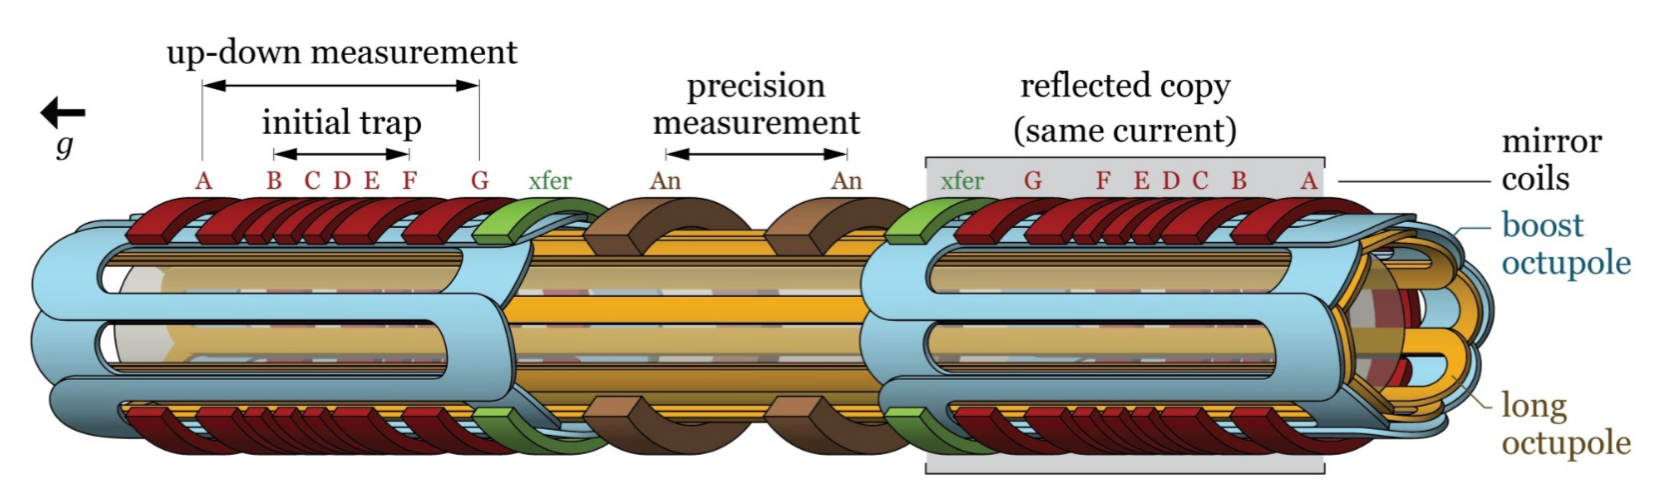



## 2D Model 

In [3]:
#some of the files are in the original folder but I made a new one for the magnets I added
path1 = 'Bfield_calculator_outputs/'
path2 = 'Bfield_calculator_outputs/Top Magnets/'

filename = path1 + "Babcock_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Position = np.array(data[:,0])*10
#Position = [p + 671-342.5+1 for p in Position] #matches positions to sequencer
Babcock_2D = np.array(data[:,1]) 


filename = path1 + "Babcock_shim_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Babcock_2D_shim = np.array(data[:,1]) 


filename = path1 + "MAGB_1A" #MaB in series with MgB
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
MirA_2D = np.array(data[:,1])


filename = path1 + "SOB_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
SoB_2D = np.array(data[:,1])


filename = path1 + "LOCT_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
LoC_2D = np.array(data[:,1])


filename = path1 + "OCT_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Oc_2D = np.array(data[:,1])

filename = path2 + "tickle"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
tickle = np.array(data[:,1])

filename = path2 + 'MB_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_B = np.array(data[:,1])

filename = path2 + 'MC_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_C = np.array(data[:,1])

filename = path2 + 'MD_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_D = np.array(data[:,1])

filename = path2 + 'ME_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_E = np.array(data[:,1])

filename = path2 + 'MF_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_F = np.array(data[:,1])

filename = path2 + 'MA_T_1A'  #MaT in series with MgT
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_AT = np.array(data[:,1])

filename = path2 + 'MbT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_bT = np.array(data[:,1])

filename = path2 + 'McT'  
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_cT = np.array(data[:,1])

filename = path2 + 'MdT'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_dT = np.array(data[:,1])

filename = path2 + 'MeT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_eT = np.array(data[:,1])*2

filename = path2 + 'MfT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_fT = np.array(data[:,1])

filename = path2 + 'OcT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Octupole_B = np.array(data[:,1])

#this will calculate the B field given some currents
def field_2D_calculation(current):
    return Babcock_2D*current[0] + MirA_2D*current[1]  + SoB_2D*current[2] + LoC_2D*current[3] + Oc_2D*current[4] + tickle*current[5] + Babcock_2D_shim*current[6] + Mirror_B*current[7] + Mirror_C*current[8] + Mirror_D*current[9] + Mirror_E*current[10] + Mirror_F*current[11] + Mirror_AT*current[12] + Mirror_bT*current[13] + Mirror_cT*current[14] + Mirror_dT*current[15] + Mirror_eT*current[16] + Mirror_fT*current[17] + Octupole_B*current[18]


In [4]:
list_stringa = ["PreGravity_20mT_well", "GravityRelease_17mT_well" ,"GravityRelease_5mT_well", "GravityRelease_2p5mT_well"] 
list_MB      = [3.4702, 2.9122, 0.9416, 0.5328]
list_targets = [-1.25, -0.75, -0.5, -0.375, -0.25, 0, 0.25, 0.5, 0.75, 1.25]

In [5]:
Zmin                 = -0.605  # m
Zmax                 = -0.481  # m
Zmid                 = -0.5434 # m
zacceptance_min      = -0.775  # m
zacceptance_max      = -0.325  # m

In [6]:
#magnet currents
B = 191 
BS = 5
MA = 0.39 #in series with MG
tickle_g = 0 
LOc = 0
Oc = 220
SB = 0


MB = 0.9416
MF = MB 

MC = 0.2767
MD = 0.2802 
ME = 0.2907 


MAT = 0 #in series with MGT
MbT = 0
McT = 0
MdT = 0
MeT = 0
MfT = 0

OcT = 0


currents =  [B,MA,SB,LOc,Oc, tickle_g, BS, MB, MC, MD, ME, MF, 0, MbT, McT, MdT, MeT, MfT, OcT]
#currents = [B,70,0,LOc,Oc, tickle_g, BS, -4.6, 1.8, 1.6, 1.8, -4.8, MAT, MbT, McT, MdT, MeT, MfT, OcT]

field_2D = field_2D_calculation(currents)
field_2D = field_2D/1e4

In [7]:
import optuna

def compute_bias_from_delta(delta: float) -> float:
    MF = MB - delta

    currents = [B, MA, SB, LOc, Oc, tickle_g, BS,
                MB, MC, MD, ME, MF,
                0, MbT, McT, MdT, MeT, MfT, OcT]

    field_2D = field_2D_calculation(currents) / 1e4

    index_mid = np.argmin(np.abs(Position - Zmid * 1e3))
    bias_g = -(np.max(field_2D[:index_mid]) - np.max(field_2D[index_mid:])) * 1e4 / 2.2
    return float(bias_g)

def objective(trial: optuna.Trial) -> float:
    # range di ricerca: scegli tu (importante!)
    delta = trial.suggest_float("delta_MB_minus_MF", -0.1, 0.1)  # esempio 0..0.2 A
    bias = compute_bias_from_delta(delta)

    # Minimizza l’errore rispetto al target
    err = abs(bias - BIAS_TARGET)

    # (opzionale) salva valori utili nei risultati
    trial.set_user_attr("bias", bias)
    trial.set_user_attr("MF", MB - delta)

    return err

In [8]:
# Save the file in Folder
# z (mm) - Bz on axis,Total potential (T) - Bz on axis,z (mm) - Min |B| on wall,Total potential (T) - Min |B| on wall

def save_file(BIAS_G, Position, field_2D):
    dtype = [
        ('z_mm__Bz_on_axis', 'f8'),
        ('Total_potential_T__Bz_on_axis', 'f8'),
    ]
    
    print(dtype[0][0])
    
    N = len(Position)
    data_new = np.empty(N, dtype=dtype)
    print(type(Position))
    
    data_new['z_mm__Bz_on_axis'] = [p for p in Position]
    data_new['Total_potential_T__Bz_on_axis'] = field_2D
    
    out_file = f"../toy/Bfield_notebook/{stringa}_{(str(round(BIAS_G,2)).replace('.','p') + 'g')}.csv"
    print(dtype[0][0] + dtype[1][0])
    
    header = dtype[0][0] + "," + dtype[1][0]
    
    np.savetxt(
        out_file,
        data_new,
        delimiter=",",
        header=header,
        comments=''   # IMPORTANTISSIMO: evita il "#"
    )

In [10]:
TOL = 1e-3  # millesimo (stessa unità del tuo bias)

def stop_when_good_enough(study: optuna.Study, trial: optuna.Trial):
    if study.best_value is not None and study.best_value <= TOL:
        study.stop()

list_biases = []
for stringa, current in zip(list_stringa,list_MB):
    MB  = current
    for bias in list_targets:
        BIAS_TARGET = bias
    
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials = 300, callbacks=[stop_when_good_enough])
        
        best = study.best_trial
        best_delta = best.params["delta_MB_minus_MF"]
        best_MF = MB - best_delta
        best_bias = best.user_attrs["bias"]
        
        print("Best delta (MB - MF) =", best_delta)
        print("Best MF =", best_MF)
        print("Bias ottenuto =", best_bias)
        print("Errore =", best.value)
    
        MF = MB - best_delta
    
        currents =  [B,MA,SB,LOc,Oc, tickle_g, BS, MB, MC, MD, ME, MF, 0, MbT, McT, MdT, MeT, MfT, OcT]
        #currents = [B,70,0,LOc,Oc, tickle_g, BS, -4.6, 1.8, 1.6, 1.8, -4.8, MAT, MbT, McT, MdT, MeT, MfT, OcT]
        
        field_2D = field_2D_calculation(currents)
        field_2D = field_2D/1e4
        BIAS_G = compute_bias_from_delta(best_delta)
        
        save_file(BIAS_G, Position, field_2D )
        list_biases.append((str(round(BIAS_G,2)).replace('.','p') + 'g'))
print( list(set(list_biases)))

[I 2026-02-07 18:19:20,027] A new study created in memory with name: no-name-a0a679da-f6d2-48c6-b2af-b04a7286fbba
[I 2026-02-07 18:19:20,030] Trial 0 finished with value: 4.2791707491853455 and parameters: {'delta_MB_minus_MF': -0.0390760155862403}. Best is trial 0 with value: 4.2791707491853455.
[I 2026-02-07 18:19:20,033] Trial 1 finished with value: 0.23062326365802366 and parameters: {'delta_MB_minus_MF': 0.05901786201391074}. Best is trial 1 with value: 0.23062326365802366.
[I 2026-02-07 18:19:20,035] Trial 2 finished with value: 3.3431888026946717 and parameters: {'delta_MB_minus_MF': -0.018717192492879814}. Best is trial 1 with value: 0.23062326365802366.
[I 2026-02-07 18:19:20,037] Trial 3 finished with value: 4.056310129142211 and parameters: {'delta_MB_minus_MF': -0.03422850762421484}. Best is trial 1 with value: 0.23062326365802366.
[I 2026-02-07 18:19:20,039] Trial 4 finished with value: 1.5562218063860311 and parameters: {'delta_MB_minus_MF': 0.08785135215270068}. Best is 

Best delta (MB - MF) = 0.05398961198120092
Best MF = 3.4162103880187993
Bias ottenuto = -1.249453159596852
Errore = 0.0005468404031478968
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis


[I 2026-02-07 18:19:21,336] Trial 34 finished with value: 0.05402169864763284 and parameters: {'delta_MB_minus_MF': 0.044300899129747405}. Best is trial 34 with value: 0.05402169864763284.
[I 2026-02-07 18:19:21,342] Trial 35 finished with value: 1.4105377934143872 and parameters: {'delta_MB_minus_MF': 0.0738068861845552}. Best is trial 34 with value: 0.05402169864763284.
[I 2026-02-07 18:19:21,348] Trial 36 finished with value: 2.0061207037843256 and parameters: {'delta_MB_minus_MF': -0.0005098740646492239}. Best is trial 34 with value: 0.05402169864763284.
[I 2026-02-07 18:19:21,355] Trial 37 finished with value: 0.8467634556117954 and parameters: {'delta_MB_minus_MF': 0.02470765198490247}. Best is trial 34 with value: 0.05402169864763284.
[I 2026-02-07 18:19:21,359] Trial 38 finished with value: 0.9317229950434733 and parameters: {'delta_MB_minus_MF': 0.06339204238217941}. Best is trial 34 with value: 0.05402169864763284.
[I 2026-02-07 18:19:21,365] Trial 39 finished with value: 1.8

Best delta (MB - MF) = 0.04310896146216398
Best MF = 3.4270910385378364
Bias ottenuto = -0.7492232393703123
Errore = 0.0007767606296876783
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis


[I 2026-02-07 18:19:21,782] Trial 36 finished with value: 5.536669348542935 and parameters: {'delta_MB_minus_MF': -0.0827417176841862}. Best is trial 11 with value: 0.04178341665364277.
[I 2026-02-07 18:19:21,788] Trial 37 finished with value: 2.122039945741263 and parameters: {'delta_MB_minus_MF': 0.08384515744785517}. Best is trial 11 with value: 0.04178341665364277.
[I 2026-02-07 18:19:21,794] Trial 38 finished with value: 0.3992346235369346 and parameters: {'delta_MB_minus_MF': 0.02900416065489156}. Best is trial 11 with value: 0.04178341665364277.
[I 2026-02-07 18:19:21,800] Trial 39 finished with value: 0.27484794883574504 and parameters: {'delta_MB_minus_MF': 0.0436663321772321}. Best is trial 11 with value: 0.04178341665364277.
[I 2026-02-07 18:19:21,806] Trial 40 finished with value: 0.9352528433136029 and parameters: {'delta_MB_minus_MF': 0.017345068134820518}. Best is trial 11 with value: 0.04178341665364277.
[I 2026-02-07 18:19:21,813] Trial 41 finished with value: 0.020892

...

Best delta (MB - MF) = -0.01137560688837704
Best MF = 0.5441756068883771
Bias ottenuto = 0.5019332901867735
Errore = 0.001933290186773462
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis


[I 2026-02-07 18:19:59,346] Trial 34 finished with value: 0.33006832380725215 and parameters: {'delta_MB_minus_MF': -0.009579188303100984}. Best is trial 17 with value: 0.04090679144826459.
[I 2026-02-07 18:19:59,351] Trial 35 finished with value: 0.014782899846801034 and parameters: {'delta_MB_minus_MF': -0.01648519793605941}. Best is trial 35 with value: 0.014782899846801034.
[I 2026-02-07 18:19:59,356] Trial 36 finished with value: 0.7914742744703211 and parameters: {'delta_MB_minus_MF': 0.0005288837793759396}. Best is trial 35 with value: 0.014782899846801034.
[I 2026-02-07 18:19:59,361] Trial 37 finished with value: 1.4938069531747407 and parameters: {'delta_MB_minus_MF': -0.0494994141942135}. Best is trial 35 with value: 0.014782899846801034.
[I 2026-02-07 18:19:59,368] Trial 38 finished with value: 3.9261158377249545 and parameters: {'delta_MB_minus_MF': 0.06946170079139781}. Best is trial 35 with value: 0.014782899846801034.
[I 2026-02-07 18:19:59,373] Trial 39 finished with va

Best delta (MB - MF) = -0.016819126553601932
Best MF = 0.549619126553602
Bias ottenuto = 0.750483872119007
Errore = 0.00048387211900702276
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis


[I 2026-02-07 18:20:00,158] Trial 25 finished with value: 1.3271425991570722 and parameters: {'delta_MB_minus_MF': 0.001310273781970041}. Best is trial 10 with value: 0.026658615484702608.
[I 2026-02-07 18:20:00,164] Trial 26 finished with value: 0.0003730295192805322 and parameters: {'delta_MB_minus_MF': -0.027742194969248297}. Best is trial 26 with value: 0.0003730295192805322.


Best delta (MB - MF) = -0.027742194969248297
Best MF = 0.5605421949692484
Bias ottenuto = 1.2496269704807195
Errore = 0.0003730295192805322
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis
['0p25g', '-0p38g', '-0p5g', '-0p37g', '0p75g', '-1p25g', '-0p0g', '0p0g', '1p25g', '0p5g', '-0p25g', '-0p75g']


In [ ]:
MF = MB - best_delta

currents =  [B,MA,SB,LOc,Oc, tickle_g, BS, MB, MC, MD, ME, MF, 0, MbT, McT, MdT, MeT, MfT, OcT]
#currents = [B,70,0,LOc,Oc, tickle_g, BS, -4.6, 1.8, 1.6, 1.8, -4.8, MAT, MbT, McT, MdT, MeT, MfT, OcT]

field_2D = field_2D_calculation(currents)
field_2D = field_2D/1e4

## Plotting

In [ ]:
# Compute Bias
index_mid = np.argmin(np.abs(Position - Zmid*1e3)) # index relative to the potential well center
print(Position[index_mid])
Bottom_Well = (field_2D)[index_mid]

massimo = np.max((field_2D)[:index_mid]); 
BIAS_G = (np.max((field_2D)[:index_mid]) - np.max((field_2D)[index_mid:]))*1e4/2.2
print(BIAS_G)

In [ ]:
plt.figure(figsize=(8,6))
plt.plot([p for p in Position], field_2D, 'b', label = f'Field Model, {BIAS_G:.2f}')

plt.ylim(Bottom_Well*0.99, massimo*1.001)
plt.xlim( -800, -300)

plt.axhline(np.max((field_2D)[:index_mid]), linestyle = "--", color = "green")
plt.axhline(np.max((field_2D)[index_mid:]), linestyle = "--", color = "green")
plt.axvline(Zmin*1e3, color = "black", linestyle = "dotted")
plt.axvline(Zmax*1e3, color = "black", linestyle = "dotted")
plt.axvline(Zmid*1e3, color = "black", linestyle = "dotted")
plt.axvline(zacceptance_min*1e3, color = "black", linestyle = "dotted")
plt.axvline(zacceptance_max*1e3, color = "black", linestyle = "dotted")
plt.legend(fontsize = 14, loc = "lower center")
format_plot('Position (mm)', 'B (T)', 'Magnetic Field Model')

In [ ]:
# plt.figure(figsize = (8,6))

# plt.plot(Position, [freq_from_bfield(b/1e4) for b in field_2D], color = 'k', label = 'Field Model')

# format_plot('Position (mm)', 'Frequency (GHz)', '')